In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [14]:
# 1. Load data
df = pd.read_csv("/Users/enhe/Library/CloudStorage/OneDrive-UniversityofBergen/R&D/UK antibiotic/UK_antibiotic_XML/data/processed/clustering_input.csv")

# 2. Select the features for clustering
features = ['Qty_Mean_Current', 'Quality_Mean_Current', 'Seasonality', 'Quantity_Trend']
X = df[features]

# 3. Scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

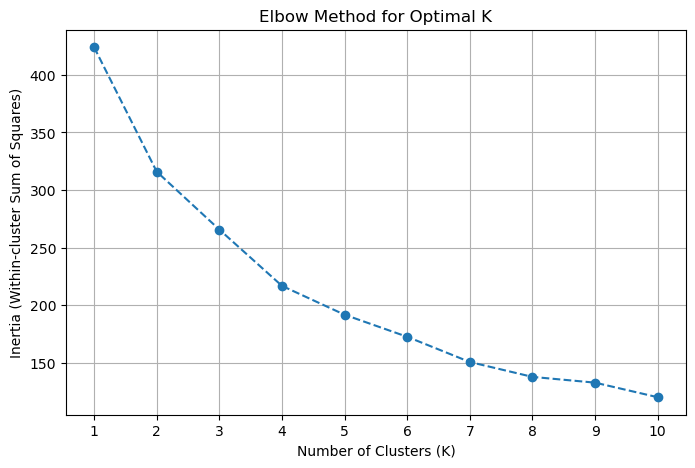

In [15]:
# 4. Elbow Method: Find optimal K
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 5. Plotting the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True)
plt.savefig('elbow_plot.png')

In [16]:
# Let's print the inertia values to see where the elbow is
print("Inertia values for K=1 to 10:")
for k, dist in zip(range(1, 11), inertia):
    print(f"K={k}: {dist:.2f}")

Inertia values for K=1 to 10:
K=1: 424.00
K=2: 315.91
K=3: 265.57
K=4: 216.69
K=5: 191.61
K=6: 172.43
K=7: 150.53
K=8: 137.60
K=9: 132.60
K=10: 119.94


In [28]:
from sklearn.cluster import KMeans

# Using K=4 for clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Group by Cluster to see the characteristics
cluster_summary = df.groupby('Cluster')[features].mean().sort_values(by='Qty_Mean_Current')

print("Cluster Summary (Means of each feature):")
print(cluster_summary)

# Count how many regions in each cluster
print("\nNumber of regions per cluster:")
print(df['Cluster'].value_counts())

# Save the final results with labels
df.to_csv("antibiotics_clustered_results.csv", index=False)

Cluster Summary (Means of each feature):
         Qty_Mean_Current  Quality_Mean_Current  Seasonality  Quantity_Trend
Cluster                                                                     
1              100.081073              8.270968     1.207769       -8.421561
2              109.295400              6.770294     1.172616      -13.314567
0              126.521337              6.574632     1.157156       -8.599607
3              130.209985              9.380417     1.206909       -8.500396

Number of regions per cluster:
Cluster
0    34
1    31
3    24
2    17
Name: count, dtype: int64


In [29]:
from sklearn.decomposition import PCA
import seaborn as sns  

In [30]:
# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

PCA Component Loadings (What each PC represents):
                           PC1       PC2
Qty_Mean_Current     -0.116151  0.799168
Quality_Mean_Current  0.604651 -0.030550
Seasonality           0.655645 -0.206122
Quantity_Trend        0.437076  0.563836


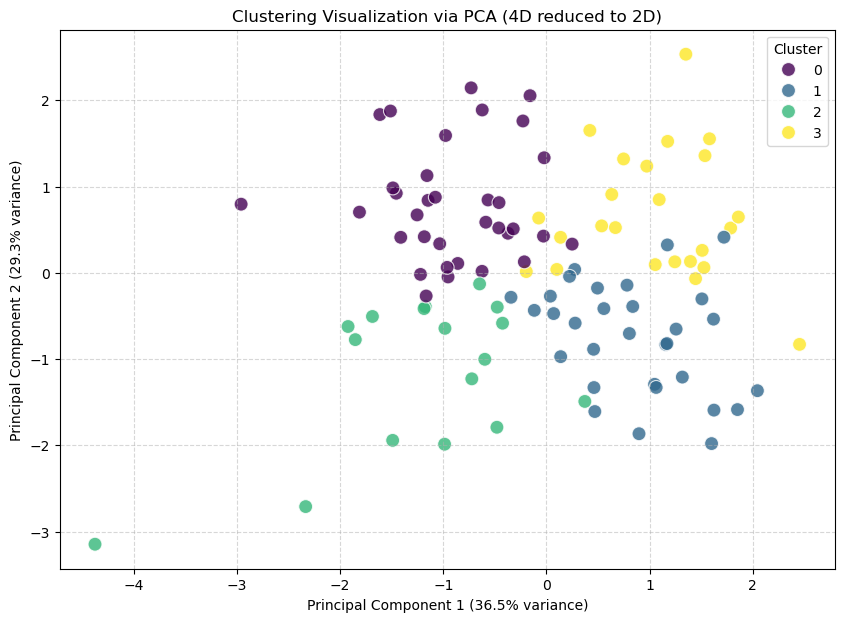

In [31]:
# Add the PCA coordinates back to the dataframe
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# 4. Plot the results
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='w'
)
# Add explained variance to labels
explained_var = pca.explained_variance_ratio_
plt.xlabel(f'Principal Component 1 ({explained_var[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_var[1]*100:.1f}% variance)')
plt.title('Clustering Visualization via PCA (4D reduced to 2D)')
plt.grid(True, linestyle='--', alpha=0.5)

# Save the plot
plt.savefig('pca_cluster_plot.png')

# Output PCA components composition (loadings) to explain what PC1/PC2 mean
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)
print("PCA Component Loadings (What each PC represents):")
print(loadings)

/var/folders/08/lczsdxgn6zq5sm8kf5csj44h0000gn/T/ipykernel_76594/3844444055.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=df, palette='viridis', ax=ax)
/var/folders/08/lczsdxgn6zq5sm8kf5csj44h0000gn/T/ipykernel_76594/3844444055.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=df, palette='viridis', ax=ax)
/var/folders/08/lczsdxgn6zq5sm8kf5csj44h0000gn/T/ipykernel_76594/3844444055.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=df, palette='vir

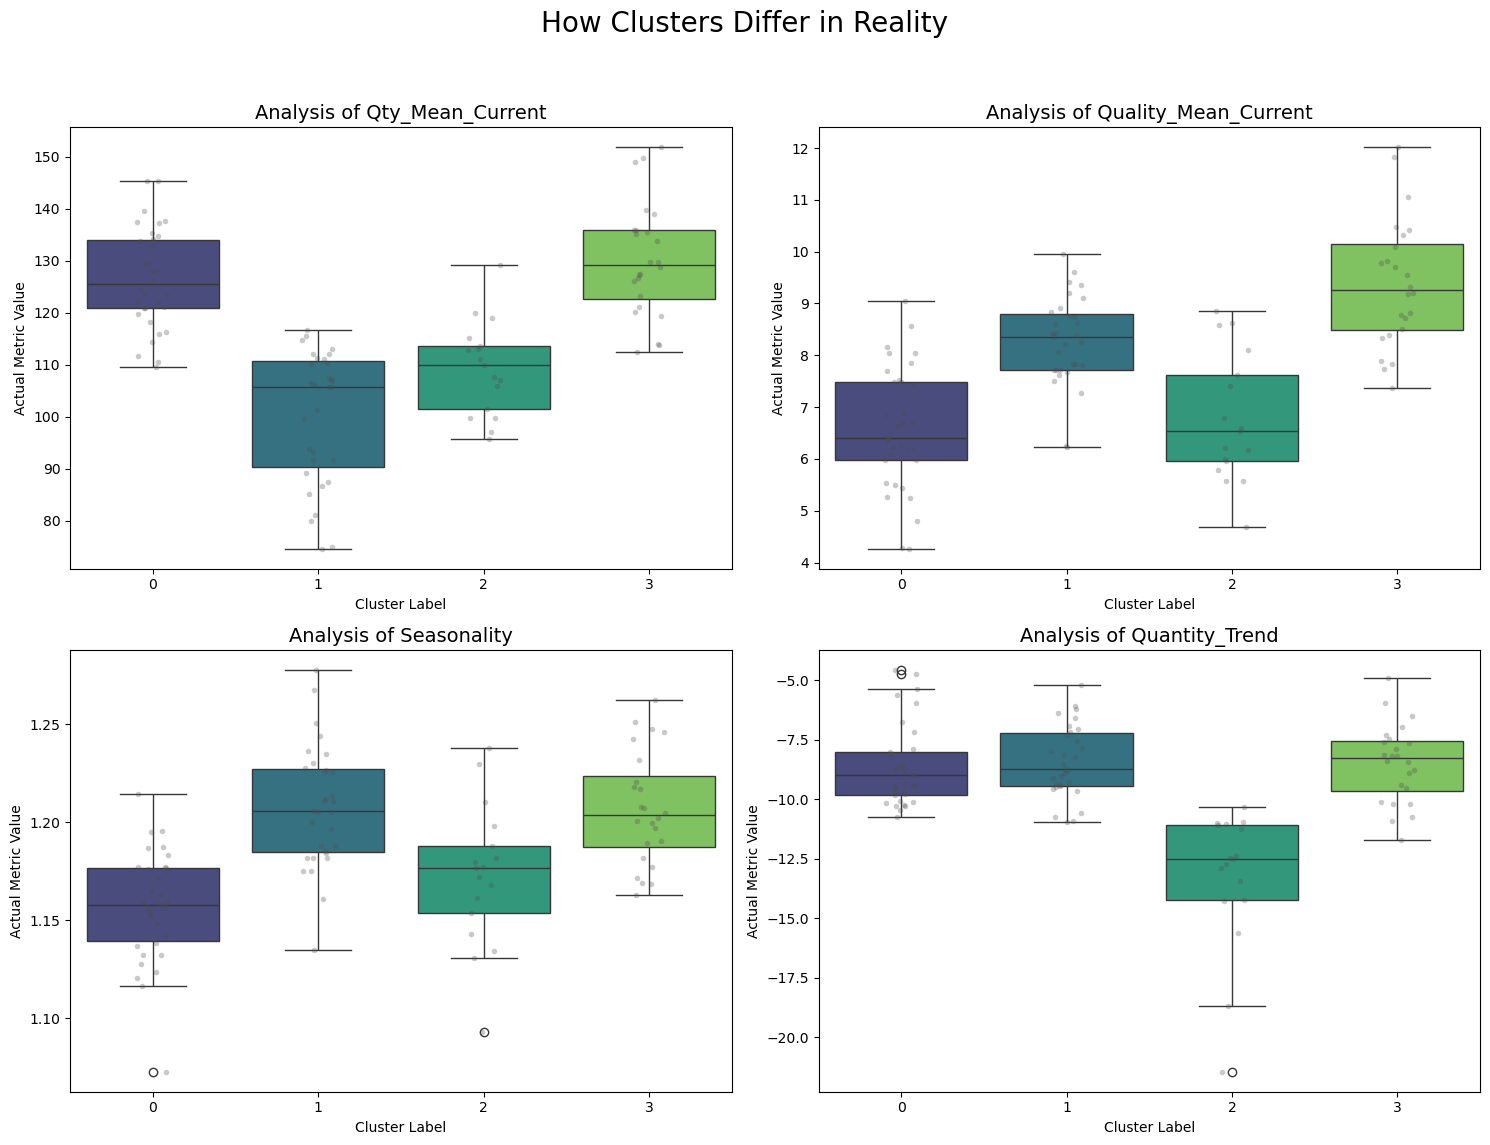

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('How Clusters Differ in Reality', fontsize=20)
for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    # 绘制箱线图：展示每个 Cluster 的分布
    sns.boxplot(x='Cluster', y=feature, data=df, palette='viridis', ax=ax)
    
    # 叠加散点：看 106 个地区的具体落点，识别“偏激”地区
    sns.stripplot(x='Cluster', y=feature, data=df, color=".3", size=4, alpha=0.3, ax=ax)
    
    ax.set_title(f'Analysis of {feature}', fontsize=14)
    ax.set_xlabel('Cluster Label')
    ax.set_ylabel('Actual Metric Value')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('cluster_phenotypes_boxplots.png')high_risk_list = df[df['Cluster'] == 3][['Area Name', 'Qty_Mean_Current', 'Quality_Mean_Current']].sort_values(by='Qty_Mean_Current', ascending=False)

In [34]:
high_risk_list = df[df['Cluster'] == 3][['Area Name', 'Qty_Mean_Current', 'Quality_Mean_Current']].sort_values(by='Qty_Mean_Current', ascending=False)
print(f" {len(high_risk_list)} in Cluster 3 ")
print(high_risk_list.head(10))

 24 in Cluster 3 
                                      Area Name  Qty_Mean_Current  \
61      Suffolk and North East Essex ICB - 07K         151.804683   
9   Staffordshire and Stoke-on-Trent ICB - 04Y         149.824147   
82                      Lincolnshire ICB - 71E         148.979955   
10               Mid and South Essex ICB - 99F         139.774235   
30      Suffolk and North East Essex ICB - 06T         139.002798   
63           Cheshire and Merseyside ICB - 12F         135.905455   
24      Suffolk and North East Essex ICB - 06L         135.870385   
49  Staffordshire and Stoke-on-Trent ICB - 05V         135.546807   
83               Norfolk and Waveney ICB - 26A         135.201455   
72      Lancashire and South Cumbria ICB - 01E         133.706173   

    Quality_Mean_Current  
61                9.1900  
9                 7.3625  
82               12.0125  
10               10.4750  
30                8.3425  
63                9.6975  
24                8.8125  
49    